# Confidence-interval plots

Loads one run directory's `training_rewards.npz` (with `rewards` `[n_seeds, n_iterations]` and a matching `seeds` array) and plots the mean training return with a 95% CI band across seeds. A single-seed run plots the mean only, with no band.

In [3]:
import os
import sys

sys.path.append("..")

import numpy as np

from utils import plot_seed_ci

In [4]:
run_dir = "../runs/Hopper/NPG/4x4"
env_id = "Hopper"

loaded curves (3, 4000) (n_seeds, n_iterations); seeds = [230  24  25]
  seed 230: final = 171.69, max = 206.88
  seed 24: final = 980.83, max = 1018.43
  seed 25: final = 1014.15, max = 1026.46
Saved CI plot: ../runs/Hopper/NPG/4x4/training_rewards_ci.png


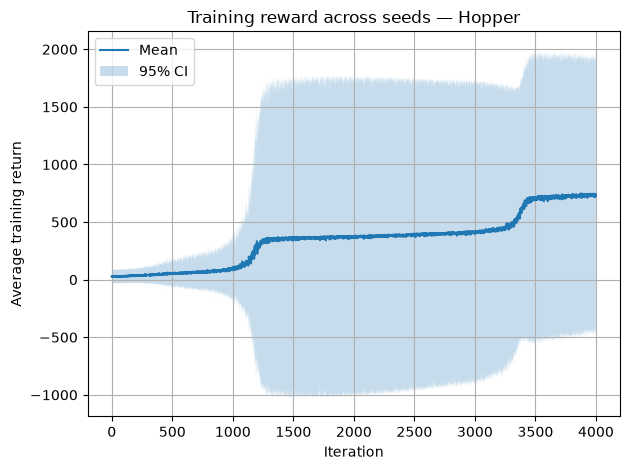

In [5]:
data = np.load(os.path.join(run_dir, "training_rewards.npz"))
curves = data["rewards"]
seeds = data["seeds"]
print(f"loaded curves {curves.shape} (n_seeds, n_iterations); seeds = {seeds}")

# Per-seed final performance, so you can spot seeds that under/over-performed.
for seed, curve in zip(seeds, curves):
    print(f"  seed {seed}: final = {curve[-1]:.2f}, max = {curve.max():.2f}")

plot_seed_ci(
    curves,
    save_path=os.path.join(run_dir, "training_rewards_ci.png"),
    title=f"Training reward across seeds — {env_id}",
)